# Reproducing Zuend et al. (2008) with `aiomfac_py`

This notebook reproduces the activity-coefficient-related figures of the first AIOMFAC journal paper:

> Zuend, A., Marcolli, C., Luo, B. P., and Peter, T.: A thermodynamic model of mixed organic–inorganic aerosols
> to predict activity coefficients, *Atmos. Chem. Phys.*, 8, 4559–4593,
> [doi:10.5194/acp-8-4559-2008](https://doi.org/10.5194/acp-8-4559-2008), 2008.

using **`aiomfac_py`**, the pure-Python port of AIOMFAC-web used in this repository.

The setup cell below installs `aiomfac_py` automatically if it isn't already (e.g. from having run `bootstrap_colab.ipynb` first in this session).

## Scope

The paper's Fig. 3–10 are attempted here, in order:

| Figure | System | Status |
|---|---|---|
| 3 | Binary Cl⁻/Br⁻ salts + water: water activity & mean activity coefficient | ✅ same salts, axes and quantities as the paper, extended into the same supersaturated regime |
| 4 | Binary NO3⁻/SO4²⁻ salts + water: water activity & mean activity coefficient | ✅ same as Fig. 3 |
| 5 | H2SO4 / (NH4)2SO4 + water: water activity & HSO4⁻ dissociation degree | ✅ both x_w conventions, 1:1/2:1/3:1 ratios, validated against our own Appendix A data |
| 6 | Multi-salt mixtures + water: water activity vs. x_w | ✅ the paper's real molar ratios (Appendix A), plus ZSR comparison |
| 7–8 | Ternary polyol + water + (NH4)2SO4: water activity vs. salt-free organic fraction | ✅ same 8 polyols/panels; 5 of 8 validated against our own Appendix A data, 3 lack data we have access to |
| 9 | NaCl/alcohol/water **liquid–liquid equilibrium** | ⚠️ **not the same figure** -- the paper's Fig. 9 needs external tie-line data we don't have; shown instead is our own `aiomfac_py.lle` module's binodal prediction for all four alcohols |
| 10 | (a) NaBr + 2-propanol + water at 353–358 K, (b) NaCl+KCl+ethanol+water at 298 K: activity coefficients | ✅ panel (a) now plots the correct quantities ($\gamma_{org}$, $\gamma_w$, not $\gamma_\pm$); panel (b) axis fixed to x_w |

**Figure 9** needs a liquid-liquid equilibrium (LLE) solver -- something `aiomfac_py`'s activity-coefficient
core does not provide on its own, since it computes activity coefficients at a *given*, single-phase
composition and does not decide whether that composition would actually split into two liquid phases. A
from-scratch Gibbs-energy-minimization LLE module, `aiomfac_py.lle`, is added below (Sec. "Figure 9") to close
that gap, porting the primal-dual interior-point algorithm of Amundson et al. (2006, JOTA 130) on top of
`ActivityModel`.

## A note on "reproducing"

None of the curves below are checked pixel-for-pixel against the published figures (no digitized data from the
paper is used) — that would need the original numerical tables, which are not published alongside the paper.
What *is* checked is internal consistency: the underlying `aiomfac_py` electrolyte and dissociation machinery
these figures exercise is validated to ~1e-14 relative precision against the instrumented AIOMFAC-web Fortran
code (see the package README). So read the plots below as **"AIOMFAC-predicted curves computed with `aiomfac_py`,
in the same style and for the same systems as Fig. X of Zuend et al. (2008)"**, not as an exact overlay of the
published figure.


### Setup

In [1]:
from pathlib import Path
import subprocess

REPO_DIR = Path("/content/aiomfac-python")

# Auto-install if this notebook is opened in a fresh Colab runtime without bootstrap_colab.ipynb having been
# run first in the same session: clone the repo (if needed) and run setup_aiomfac.py, exactly what
# bootstrap_colab.ipynb itself does. If aiomfac_py is already importable (bootstrap_colab.ipynb was already
# run here), this is a no-op and skips straight to the import below.
try:
    import aiomfac_py as aiomfac
except ImportError:
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", "https://github.com/SeoulTechPSE/aiomfac-python.git", str(REPO_DIR)],
                        check=True)
    get_ipython().run_line_magic("run", f"{REPO_DIR / 'setup_aiomfac.py'} --carbonate")
    import aiomfac_py as aiomfac

import numpy as np
import matplotlib.pyplot as plt
from aiomfac_py import Component, ActivityModel

print(f"aiomfac_py {aiomfac.__version__}")

aiomfac_py 0.0.11


### Shared helpers

Two things the paper's figures need that `aiomfac_py` does not return directly (it returns per-species
ln(activity coefficient), not a combined electrolyte quantity):

* **Water activity** is already available directly as `res.activity[0]` (the neutral-component activity), used as-is.
* **Mean molal activity coefficient** \(\gamma_\pm\) of a binary (or, here, pseudo-binary) electrolyte is the
  standard electrochemistry combination of the per-ion activity coefficients,
  \(\gamma_\pm = (\gamma_+^{\nu_+} \gamma_-^{\nu_-})^{1/(\nu_++\nu_-)}\), computed here from
  `res.ln_gamma` (which already holds each ion's ln(activity coefficient) on the molality basis, in
  neutrals-then-cations-then-anions order) via each ion's index in `model.mixture.cat_index` /
  `model.mixture.an_index`.

Both are new, small post-processing code written for this notebook -- not part of the `aiomfac_py` package
itself.

In [2]:
def mean_gamma_pm(model, res, cat_subgroup, an_subgroup, nu_c, nu_a):
    """Mean molal activity coefficient of a single cation/anion pair (nu_c cations : nu_a anions per formula unit)."""
    m = model.mixture
    nn, nc = m.n_neutral, m.sr.n_cation
    i = m.cat_index[cat_subgroup]
    j = m.an_index[an_subgroup]
    ln_c = res.ln_gamma[nn + i]
    ln_a = res.ln_gamma[nn + nc + j]
    return np.exp((nu_c * ln_c + nu_a * ln_a) / (nu_c + nu_a))


def water_activity(res):
    return res.activity[0]


def m_max_for_xw(n_ions, xw_target=0.12):
    """Molality (mol/kg water) at which the fully-dissociated-basis mole fraction of water reaches
    xw_target, for a salt that dissociates into n_ions ions per formula unit. Used to push
    binary_salt_sweep well past each salt's real (sub)saturation solubility limit and into the
    supersaturated regime that AIOMFAC-web is deliberately parametrised to remain numerically
    well-defined in -- matching the original Fig. 3/4 caption: "At very high concentrations, beyond
    the efflorescence of supersaturated solutions, the curves are model predictions without direct
    experimental support." (Zuend et al., 2008)"""
    water_molal = 1000.0 / 18.015   # mol water per kg water, i.e. per kg of solvent
    return water_molal * (1 - xw_target) / (xw_target * n_ions)


def binary_salt_sweep(cat_subgroup, an_subgroup, nu_c, nu_a, M_salt, m_max, T_K=298.15, n=22):
    """Water + one salt, swept over molality 0 < m <= m_max mol/kg-water. Returns (x_water, aw, gamma_pm)."""
    water = Component(1, "Water", ((16, 1),))
    salt = Component(2, "salt", ((cat_subgroup, nu_c), (an_subgroup, nu_a)))
    model = ActivityModel([water, salt])
    molalities = np.geomspace(m_max / 200, m_max, n)
    xw, aw, gpm = [], [], []
    for molal in molalities:
        w_salt = molal * M_salt / (1000.0 + molal * M_salt)
        res = model.evaluate([1 - w_salt, w_salt], T_K, basis="mass")
        xw.append(res.x[0])
        aw.append(water_activity(res))
        gpm.append(mean_gamma_pm(model, res, cat_subgroup, an_subgroup, nu_c, nu_a))
    return np.array(xw), np.array(aw), np.array(gpm), molalities


def fig_pair(title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
    fig.suptitle(title)
    ax1.set_xlabel("$x_{w}$ (mole fraction water, dissociated basis)")
    ax1.set_ylabel("water activity $a_w$")
    ax2.set_xlabel("$x_{w}$ (mole fraction water, dissociated basis)")
    ax2.set_ylabel(r"mean activity coefficient $\gamma_\pm$")
    return fig, ax1, ax2

## Figure 3 -- Binary Cl⁻ and Br⁻ salts + water (298.15 K)

Water activity and mean molal activity coefficient vs. mole fraction of water, swept from dilute all the way into the supersaturated regime (down to a dissociated-basis $x_w \approx 0.12$ for every salt, well past real solubility), for a representative set of the paper's Cl⁻ and Br⁻ salts -- matching how the original Fig. 3 extends its modelled curves beyond the efflorescence point. The $\gamma_\pm$ panels are clipped to the same y-range as the original figure, since a few ions (H⁺, Li⁺ in particular) extrapolate to very large activity coefficients at extreme concentration; the curves keep going up, off-scale, just as in the original.

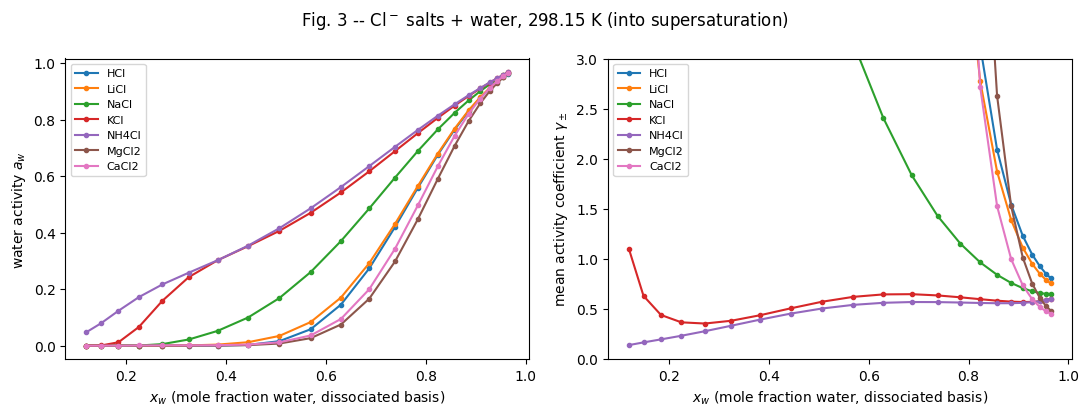

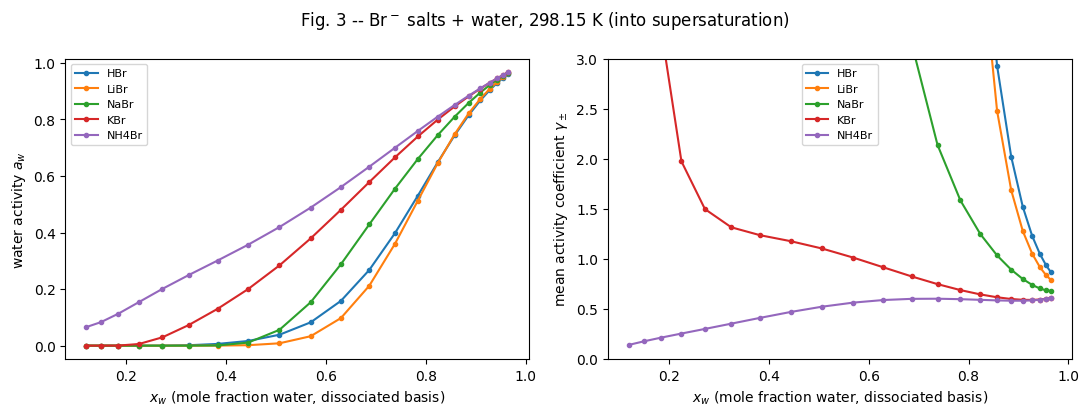

In [3]:
# subgroup 205=H+, 201=Li+, 202=Na+, 203=K+, 204=NH4+, 223=Mg2+, 221=Ca2+, 242=Cl-, 243=Br-
# entries: (name, cation subgroup, anion subgroup, nu_cation, nu_anion, M_salt [g/mol])
cl_salts = [
    ("HCl",    205, 242, 1, 1, 36.46),
    ("LiCl",   201, 242, 1, 1, 42.39),
    ("NaCl",   202, 242, 1, 1, 58.44),
    ("KCl",    203, 242, 1, 1, 74.55),
    ("NH4Cl",  204, 242, 1, 1, 53.49),
    ("MgCl2",  223, 242, 1, 2, 95.21),
    ("CaCl2",  221, 242, 1, 2, 110.98),
]
br_salts = [
    ("HBr",    205, 243, 1, 1, 80.91),
    ("LiBr",   201, 243, 1, 1, 86.85),
    ("NaBr",   202, 243, 1, 1, 102.89),
    ("KBr",    203, 243, 1, 1, 119.00),
    ("NH4Br",  204, 243, 1, 1, 97.94),
]

fig, ax1, ax2 = fig_pair("Fig. 3 -- Cl$^-$ salts + water, 298.15 K (into supersaturation)")
for name, cat, an, nu_c, nu_a, M in cl_salts:
    xw, aw, gpm, _ = binary_salt_sweep(cat, an, nu_c, nu_a, M, m_max_for_xw(nu_c + nu_a))
    ax1.plot(xw, aw, marker="o", ms=3, label=name)
    ax2.plot(xw, gpm, marker="o", ms=3, label=name)
ax1.legend(fontsize=8); ax2.legend(fontsize=8)
ax2.set_ylim(0, 3)
plt.tight_layout(); plt.show()

fig, ax1, ax2 = fig_pair("Fig. 3 -- Br$^-$ salts + water, 298.15 K (into supersaturation)")
for name, cat, an, nu_c, nu_a, M in br_salts:
    xw, aw, gpm, _ = binary_salt_sweep(cat, an, nu_c, nu_a, M, m_max_for_xw(nu_c + nu_a))
    ax1.plot(xw, aw, marker="o", ms=3, label=name)
    ax2.plot(xw, gpm, marker="o", ms=3, label=name)
ax1.legend(fontsize=8); ax2.legend(fontsize=8)
ax2.set_ylim(0, 3)
plt.tight_layout(); plt.show()


## Figure 4 -- Binary NO3⁻ and SO4²⁻ salts + water (298.15 K)

Same axes and same supersaturated extension as Fig. 3, for the paper's nitrate and sulfate salts.

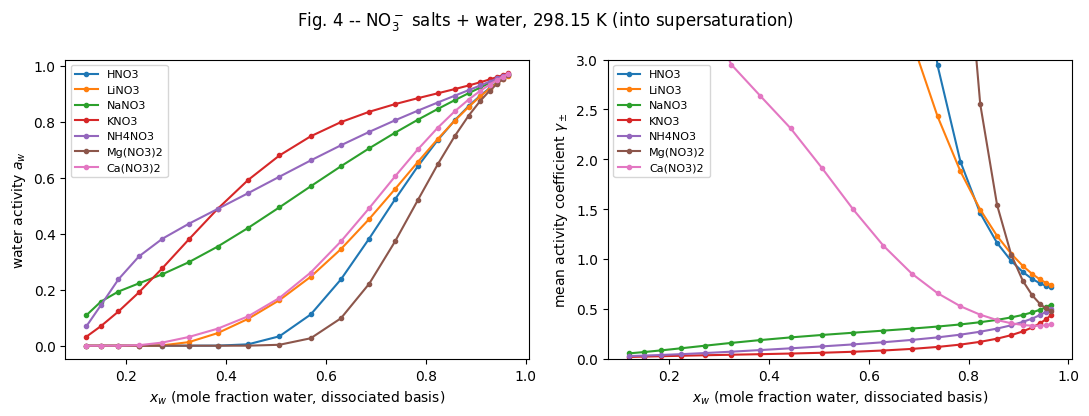

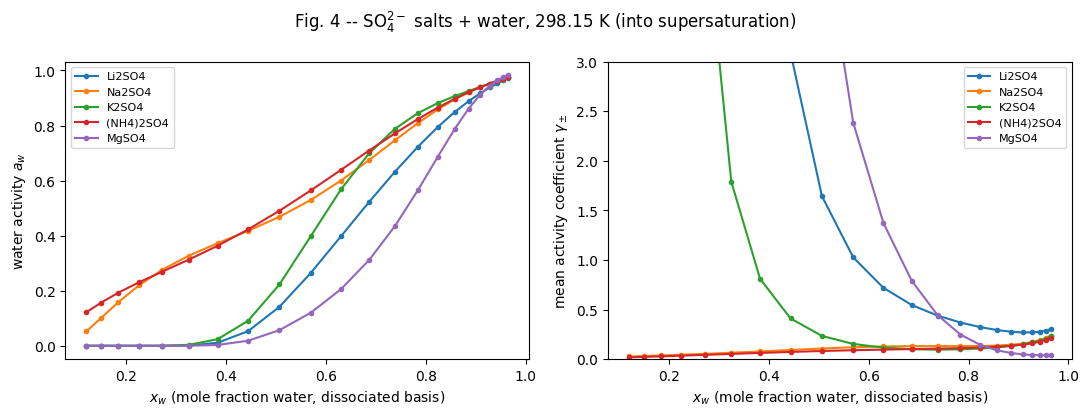

In [4]:
# 245 = NO3-, 261 = SO4--
# entries: (name, cation subgroup, anion subgroup, nu_cation, nu_anion, M_salt [g/mol])
no3_salts = [
    ("HNO3",      205, 245, 1, 1, 63.01),
    ("LiNO3",     201, 245, 1, 1, 68.95),
    ("NaNO3",     202, 245, 1, 1, 84.99),
    ("KNO3",      203, 245, 1, 1, 101.10),
    ("NH4NO3",    204, 245, 1, 1, 80.04),
    ("Mg(NO3)2",  223, 245, 1, 2, 148.32),
    ("Ca(NO3)2",  221, 245, 1, 2, 164.09),
]
so4_salts = [
    ("Li2SO4",     201, 261, 2, 1, 109.94),
    ("Na2SO4",     202, 261, 2, 1, 142.04),
    ("K2SO4",      203, 261, 2, 1, 174.25),
    ("(NH4)2SO4",  204, 261, 2, 1, 132.14),
    ("MgSO4",      223, 261, 1, 1, 120.37),
]

fig, ax1, ax2 = fig_pair("Fig. 4 -- NO$_3^-$ salts + water, 298.15 K (into supersaturation)")
for name, cat, an, nu_c, nu_a, M in no3_salts:
    xw, aw, gpm, _ = binary_salt_sweep(cat, an, nu_c, nu_a, M, m_max_for_xw(nu_c + nu_a))
    ax1.plot(xw, aw, marker="o", ms=3, label=name)
    ax2.plot(xw, gpm, marker="o", ms=3, label=name)
ax1.legend(fontsize=8); ax2.legend(fontsize=8)
ax2.set_ylim(0, 3)
plt.tight_layout(); plt.show()

fig, ax1, ax2 = fig_pair("Fig. 4 -- SO$_4^{2-}$ salts + water, 298.15 K (into supersaturation)")
for name, cat, an, nu_c, nu_a, M in so4_salts:
    xw, aw, gpm, _ = binary_salt_sweep(cat, an, nu_c, nu_a, M, m_max_for_xw(nu_c + nu_a))
    ax1.plot(xw, aw, marker="o", ms=3, label=name)
    ax2.plot(xw, gpm, marker="o", ms=3, label=name)
ax1.legend(fontsize=8); ax2.legend(fontsize=8)
ax2.set_ylim(0, 3)
plt.tight_layout(); plt.show()


## Figure 5 -- H2SO4 and (NH4)2SO4 + water (298.15 K): water activity and HSO4⁻ dissociation

The paper's Fig. 5 has two x-axis conventions plotted side by side: panel (a) assumes **complete** dissociation of both H2SO4 and (NH4)2SO4 (3 ions each) for $x_w$; panel (b) uses the **actual, partially dissociated** HSO4⁻ population that the model (and reality) actually has, which is what `ActivityModel` returns as `res.x[0]` once it has solved the H+/HSO4⁻/SO4²⁻ equilibrium. Both panels show pure H2SO4, pure (NH4)2SO4, and their 1:1, 2:1, 3:1 (NH4)2SO4:H2SO4 molar mixtures, with the corresponding $\alpha_{HSO_4^-}$ dissociation degree underneath. The red '×' markers are our own bulk water-activity measurements at the 2:1 ratio (Table A1 of the paper's Appendix A, 298.15 K) -- real data, not digitized from a plot.

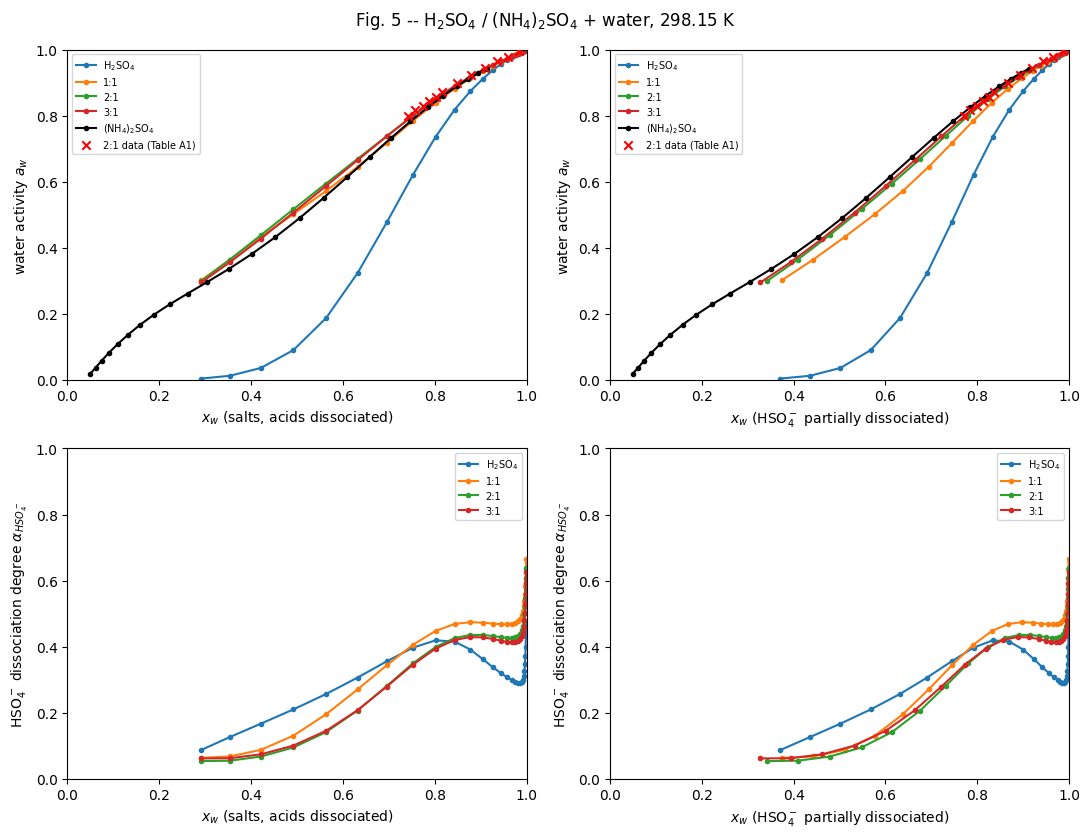

In [5]:
water = Component(1, "Water", ((16, 1),))
M_h2so4, M_nh4so4 = 98.079, 132.14
water_molal = 1000.0 / 18.015


def xw_full_diss(m_h2so4, m_nh4so4):
    """x_w assuming complete dissociation of BOTH H2SO4 and (NH4)2SO4 (3 ions each) -- Fig. 5 panel (a)'s
    x-axis convention, ignoring the model's own partial bisulfate association."""
    return water_molal / (water_molal + 3.0 * (m_h2so4 + m_nh4so4))


def h2so4_nh4so4_model():
    h2so4 = Component(2, "H2SO4", ((205, 2), (261, 1)))
    nh4so4 = Component(3, "(NH4)2SO4", ((204, 2), (261, 1)))
    return ActivityModel([water, h2so4, nh4so4])


def sweep_h2so4_nh4so4(ratio_nh4so4_to_h2so4, tot_S_grid):
    """Sweep total sulfate-equivalent molality at a fixed (NH4)2SO4:H2SO4 molar ratio."""
    model = h2so4_nh4so4_model()
    idx_hso4 = model.mixture.an_index[248]
    r = ratio_nh4so4_to_h2so4
    xw_full, xw_part, aw, alpha = [], [], [], []
    for tot_S in tot_S_grid:
        m_nh4so4 = tot_S * r / (1 + r)
        m_h2so4 = tot_S / (1 + r)
        w1, w2 = m_h2so4 * M_h2so4 / 1000.0, m_nh4so4 * M_nh4so4 / 1000.0
        tot = 1.0 + w1 + w2
        res = model.evaluate([1 / tot, w1 / tot, w2 / tot], 298.15, basis="mass")
        m_hso4max = min(m_h2so4 + m_nh4so4, 2 * m_h2so4) if m_h2so4 > 0 else 0.0
        alpha.append((1.0 - res.sma[idx_hso4] / m_hso4max) if m_hso4max > 0 else np.nan)
        xw_full.append(xw_full_diss(m_h2so4, m_nh4so4))
        xw_part.append(res.x[0])
        aw.append(res.activity[0])
    return map(np.array, (xw_full, xw_part, aw, alpha))


tot_S_grid = np.geomspace(0.02, 45.0, 28)
ratios = {"H$_2$SO$_4$": 0.0, "1:1": 1.0, "2:1": 2.0, "3:1": 3.0}
curves = {name: sweep_h2so4_nh4so4(r, tot_S_grid) for name, r in ratios.items()}

# pure (NH4)2SO4: no bisulfate system at all -- reuse the plain binary sweep from Fig. 3/4
xw2, aw_nh4so4, _, _ = binary_salt_sweep(204, 261, 2, 1, 132.14, m_max_for_xw(3, xw_target=0.05), n=26)

# Appendix A, Table A1: our own bulk a_w measurements at (NH4)2SO4:H2SO4 = 2:1 (molar), 298.15 K
table_a1 = np.array([
    [0.0247, 0.0092, 0.995], [0.0611, 0.0227, 0.978], [0.0977, 0.0362, 0.966],
    [0.1340, 0.0497, 0.945], [0.1704, 0.0633, 0.924], [0.2068, 0.0768, 0.900],
    [0.2433, 0.0903, 0.870], [0.2583, 0.0958, 0.856], [0.2733, 0.1014, 0.843],
    [0.2882, 0.1070, 0.829], [0.3036, 0.1127, 0.816], [0.3181, 0.1181, 0.799],
])
model21 = h2so4_nh4so4_model()
data_xwfull, data_xwpart = [], []
for w_nh4so4, w_h2so4, aw_meas in table_a1:
    w_w = 1 - w_nh4so4 - w_h2so4
    res = model21.evaluate([w_w, w_h2so4, w_nh4so4], 298.15, basis="mass")
    m_h2so4 = w_h2so4 / M_h2so4 * 1000.0 / w_w
    m_nh4so4 = w_nh4so4 / M_nh4so4 * 1000.0 / w_w
    data_xwfull.append(xw_full_diss(m_h2so4, m_nh4so4))
    data_xwpart.append(res.x[0])
aw_meas_a1 = table_a1[:, 2]

fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
fig.suptitle("Fig. 5 -- H$_2$SO$_4$ / (NH$_4$)$_2$SO$_4$ + water, 298.15 K")
for name in ratios:
    xw_full, xw_part, aw, alpha = curves[name]
    axes[0, 0].plot(xw_full, aw, marker="o", ms=3, label=name)
    axes[0, 1].plot(xw_part, aw, marker="o", ms=3, label=name)
    if name != "H$_2$SO$_4$":
        axes[1, 0].plot(xw_full, alpha, marker="o", ms=3, label=name)
        axes[1, 1].plot(xw_part, alpha, marker="o", ms=3, label=name)
    else:
        axes[1, 0].plot(xw_full, alpha, marker="o", ms=3, label=name)
        axes[1, 1].plot(xw_part, alpha, marker="o", ms=3, label=name)
axes[0, 0].plot(xw2, aw_nh4so4, marker="o", ms=3, color="k", label="(NH$_4$)$_2$SO$_4$")
axes[0, 1].plot(xw2, aw_nh4so4, marker="o", ms=3, color="k", label="(NH$_4$)$_2$SO$_4$")
axes[0, 0].scatter(data_xwfull, aw_meas_a1, marker="x", color="red", zorder=5, label="2:1 data (Table A1)")
axes[0, 1].scatter(data_xwpart, aw_meas_a1, marker="x", color="red", zorder=5, label="2:1 data (Table A1)")

for ax, xlabel in [(axes[0, 0], "$x_w$ (salts, acids dissociated)"),
                    (axes[0, 1], "$x_w$ (HSO$_4^-$ partially dissociated)")]:
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel(xlabel); ax.set_ylabel("water activity $a_w$")
    ax.legend(fontsize=7)
for ax, xlabel in [(axes[1, 0], "$x_w$ (salts, acids dissociated)"),
                    (axes[1, 1], "$x_w$ (HSO$_4^-$ partially dissociated)")]:
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel(xlabel); ax.set_ylabel(r"HSO$_4^-$ dissociation degree $\alpha_{HSO_4^-}$")
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()


## Figure 6 -- Multi-salt mixtures + water (298.15 K)

Both panels now use the paper's actual salt ratios (from its Appendix A) and $x_w$ (salts dissociated) on the x-axis, matching the original figure. **(a)** NaCl + NH4NO3 at a 1:1 molar ratio (Table A3), compared against the two binary parent-salt curves and two ZSR-relation predictions -- ZSR1 decomposes the ion mixture as NaCl + NH4NO3, ZSR2 as NaNO3 + NH4Cl (both are equally valid decompositions of the same Na+/NH4+/Cl-/NO3- ion mixture). The ZSR curves here are computed from `aiomfac_py`'s own binary-salt predictions (inverted to give molality as a function of water activity), not digitized from the paper's cited polynomials -- so this checks internal self-consistency of the port rather than reproducing the paper's exact ZSR curve. **(b)** the real "sea salt"-like mixture, NaCl:Na2SO4:MgCl2 = 14.820:1.000:1.895 molar (Table A5), against its three binary parent salts plus MgSO4 for comparison (as in the original). Red '×' markers in both panels are our own bulk water-activity measurements (Tables A3, A5).

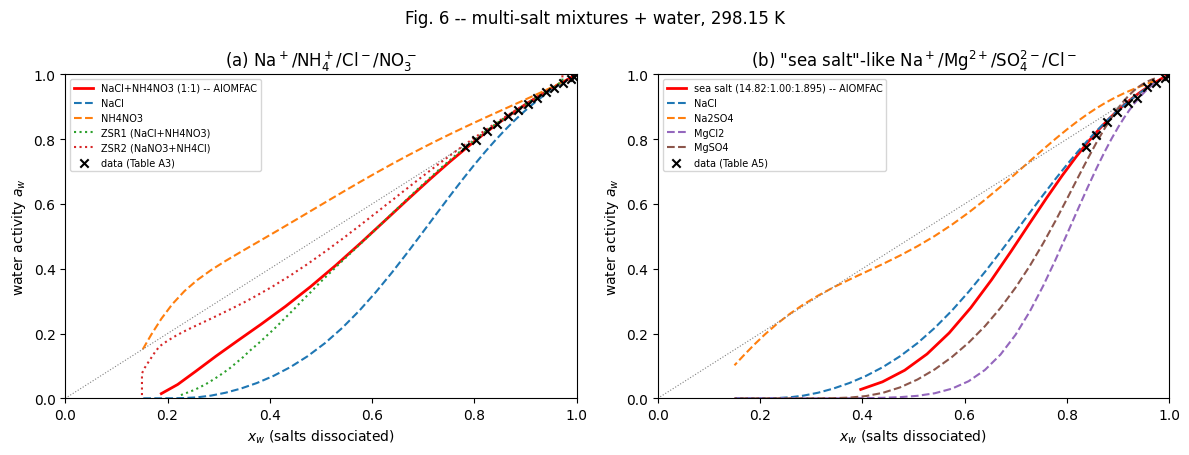

In [6]:
water = Component(1, "Water", ((16, 1),))


def binary_curve(cat, an, M, m_max, n=40):
    xw, aw, _, molal = binary_salt_sweep(cat, an, 1, 1, M, m_max, n=n)
    return molal, xw, aw


def inv_aw_to_m(molal, aw):
    order = np.argsort(aw)
    aw_s, m_s = np.asarray(aw)[order], np.asarray(molal)[order]
    return lambda aw_q: np.interp(aw_q, aw_s, m_s)


def zsr_xw(f_m1, f_m2, aw_grid):
    """ZSR prediction (1:1 molal mix of two parent salts, each dissociating into 2 ions) as x_w(aw)."""
    out = []
    for awq in aw_grid:
        m01, m02 = f_m1(awq), f_m2(awq)
        t = 1.0 / (1.0 / m01 + 1.0 / m02)
        out.append(water_molal / (water_molal + 2 * t + 2 * t))
    return np.array(out)


# --- panel (a): NaCl + NH4NO3, 1:1 molar ---
nacl_comp = Component(2, "NaCl", ((202, 1), (242, 1)))
nh4no3_comp = Component(3, "NH4NO3", ((204, 1), (245, 1)))
model_a = ActivityModel([water, nacl_comp, nh4no3_comp])
M_nacl, M_nh4no3 = 58.44, 80.04
m_grid_a = np.geomspace(0.01, 60.0, 45)
xw_a, aw_a = [], []
for m in m_grid_a:
    w1, w2 = m * M_nacl / 1000.0, m * M_nh4no3 / 1000.0
    tot = 1 + w1 + w2
    res = model_a.evaluate([1 / tot, w1 / tot, w2 / tot], 298.15, basis="mass")
    xw_a.append(res.x[0]); aw_a.append(res.activity[0])
xw_a, aw_a = np.array(xw_a), np.array(aw_a)

m_nacl, xw_nacl, aw_nacl = binary_curve(202, 242, M_nacl, m_max_for_xw(2, 0.15))
m_nh4no3, xw_nh4no3, aw_nh4no3 = binary_curve(204, 245, M_nh4no3, m_max_for_xw(2, 0.15))
m_nano3, xw_nano3, aw_nano3 = binary_curve(202, 245, 84.99, m_max_for_xw(2, 0.15))
m_nh4cl, xw_nh4cl, aw_nh4cl = binary_curve(204, 242, 53.49, m_max_for_xw(2, 0.15))

aw_grid = np.linspace(0.01, 0.999, 60)
xw_zsr1 = zsr_xw(inv_aw_to_m(m_nacl, aw_nacl), inv_aw_to_m(m_nh4no3, aw_nh4no3), aw_grid)
xw_zsr2 = zsr_xw(inv_aw_to_m(m_nano3, aw_nano3), inv_aw_to_m(m_nh4cl, aw_nh4cl), aw_grid)

table_a3 = np.array([
    [0.0038, 0.0052, 0.991], [0.0093, 0.0127, 0.985], [0.0207, 0.0283, 0.973],
    [0.0338, 0.0462, 0.959], [0.0456, 0.0624, 0.946], [0.0591, 0.0809, 0.928],
    [0.0709, 0.0971, 0.910], [0.0844, 0.1156, 0.891], [0.0967, 0.1323, 0.872],
    [0.1102, 0.1508, 0.847], [0.1220, 0.1670, 0.824], [0.1351, 0.1849, 0.799],
    [0.1478, 0.2022, 0.775],
])
data_xw_a = []
for w_nacl, w_nh4no3, aw_meas in table_a3:
    res = model_a.evaluate([1 - w_nacl - w_nh4no3, w_nacl, w_nh4no3], 298.15, basis="mass")
    data_xw_a.append(res.x[0])

fig, (axa, axb) = plt.subplots(1, 2, figsize=(12, 4.6))
fig.suptitle("Fig. 6 -- multi-salt mixtures + water, 298.15 K")
axa.plot(xw_a, aw_a, "-", color="red", lw=2, label="NaCl+NH4NO3 (1:1) -- AIOMFAC")
axa.plot(xw_nacl, aw_nacl, "--", color="C0", label="NaCl")
axa.plot(xw_nh4no3, aw_nh4no3, "--", color="C1", label="NH4NO3")
axa.plot(xw_zsr1, aw_grid, ":", color="C2", label="ZSR1 (NaCl+NH4NO3)")
axa.plot(xw_zsr2, aw_grid, ":", color="C3", label="ZSR2 (NaNO3+NH4Cl)")
axa.scatter(data_xw_a, table_a3[:, 2], marker="x", color="k", zorder=5, label="data (Table A3)")
axa.plot([0, 1], [0, 1], ":", color="gray", lw=0.8)
axa.set_xlim(0, 1); axa.set_ylim(0, 1)
axa.set_xlabel("$x_w$ (salts dissociated)"); axa.set_ylabel("water activity $a_w$")
axa.set_title("(a) Na$^+$/NH$_4^+$/Cl$^-$/NO$_3^-$"); axa.legend(fontsize=7)

# --- panel (b): "sea salt" NaCl:Na2SO4:MgCl2 = 14.820:1.000:1.895 molar ---
na2so4_comp = Component(2, "Na2SO4", ((202, 2), (261, 1)))
nacl_comp2 = Component(3, "NaCl", ((202, 1), (242, 1)))
mgcl2_comp = Component(4, "MgCl2", ((223, 1), (242, 2)))
model_b = ActivityModel([water, na2so4_comp, nacl_comp2, mgcl2_comp])
M_na2so4, M_mgcl2 = 142.04, 95.21
ratio_b = np.array([1.000, 14.820, 1.895])   # Na2SO4, NaCl, MgCl2
t_grid = np.geomspace(0.001, 2.2, 45)
xw_b, aw_b = [], []
for t in t_grid:
    m = t * ratio_b
    w = m * np.array([M_na2so4, M_nacl, M_mgcl2]) / 1000.0
    tot = 1 + w.sum()
    res = model_b.evaluate([1 / tot, w[0] / tot, w[1] / tot, w[2] / tot], 298.15, basis="mass")
    xw_b.append(res.x[0]); aw_b.append(res.activity[0])
xw_b, aw_b = np.array(xw_b), np.array(aw_b)

m_mgso4, xw_mgso4, aw_mgso4 = binary_curve(223, 261, 120.37, m_max_for_xw(2, 0.15))

table_a5 = np.array([
    [0.0029, 0.0005, 0.0006, 0.994], [0.0102, 0.0017, 0.0021, 0.989], [0.0321, 0.0053, 0.0067, 0.975],
    [0.0532, 0.0087, 0.0111, 0.961], [0.0743, 0.0122, 0.0155, 0.926], [0.0962, 0.0158, 0.0200, 0.913],
    [0.1180, 0.0194, 0.0246, 0.884], [0.1399, 0.0229, 0.0291, 0.852], [0.1618, 0.0265, 0.0337, 0.814],
    [0.1822, 0.0299, 0.0380, 0.777],
])
data_xw_b = []
for w_nacl, w_na2so4, w_mgcl2, aw_meas in table_a5:
    ww = 1 - w_nacl - w_na2so4 - w_mgcl2
    res = model_b.evaluate([ww, w_na2so4, w_nacl, w_mgcl2], 298.15, basis="mass")
    data_xw_b.append(res.x[0])

axb.plot(xw_b, aw_b, "-", color="red", lw=2, label="sea salt (14.82:1.00:1.895) -- AIOMFAC")
axb.plot(xw_nacl, aw_nacl, "--", color="C0", label="NaCl")
m_na2so4b, xw_na2so4, aw_na2so4 = binary_curve(202, 261, M_na2so4, m_max_for_xw(3, 0.15))
axb.plot(xw_na2so4, aw_na2so4, "--", color="C1", label="Na2SO4")
m_mgcl2b, xw_mgcl2, aw_mgcl2 = binary_curve(223, 242, M_mgcl2, m_max_for_xw(3, 0.15))
axb.plot(xw_mgcl2, aw_mgcl2, "--", color="C4", label="MgCl2")
axb.plot(xw_mgso4, aw_mgso4, "--", color="C5", label="MgSO4")
axb.scatter(data_xw_b, table_a5[:, 3], marker="x", color="k", zorder=5, label="data (Table A5)")
axb.plot([0, 1], [0, 1], ":", color="gray", lw=0.8)
axb.set_xlim(0, 1); axb.set_ylim(0, 1)
axb.set_xlabel("$x_w$ (salts dissociated)"); axb.set_ylabel("water activity $a_w$")
axb.set_title("(b) \"sea salt\"-like Na$^+$/Mg$^{2+}$/SO$_4^{2-}$/Cl$^-$"); axb.legend(fontsize=7)
plt.tight_layout(); plt.show()


## Figures 7-8 -- Ternary polyol + water + (NH4)2SO4 (298.15 K)

Water activity vs. the salt-free organic mole fraction \(x'_{org} = x_{org}/(x_{org}+x_w)\), one panel per polyol exactly as in the paper (Fig. 7: glycerol, 1,2,4-butanetriol, 1,2-butanediol, 1,4-butanediol; Fig. 8: 2,4-pentanediol, 1,2-hexanediol, 2,5-hexanediol, 1,7-heptanediol). Organic subgroups come from `aiomfac_py.s2as` (hard-coded below so this section has no `epam.indigo` dependency). The '×' markers and the bar sub-panels (mole-fraction breakdown $X_w$/$X_{org}$/$X_{ions}$, fully-dissociated basis) use our own real bulk water-activity measurements from the paper's Appendix A (Tables A7-A9) -- for glycerol, 1,4-butanediol, and 1,2-hexanediol the paper's data instead comes from Marcolli and Krieger (2006), which is *not* reproduced here (we don't have that paper's digitized numbers), so those three panels show only the AIOMFAC salt-free-mixture reference curve, with no data overlay and no bar panel.

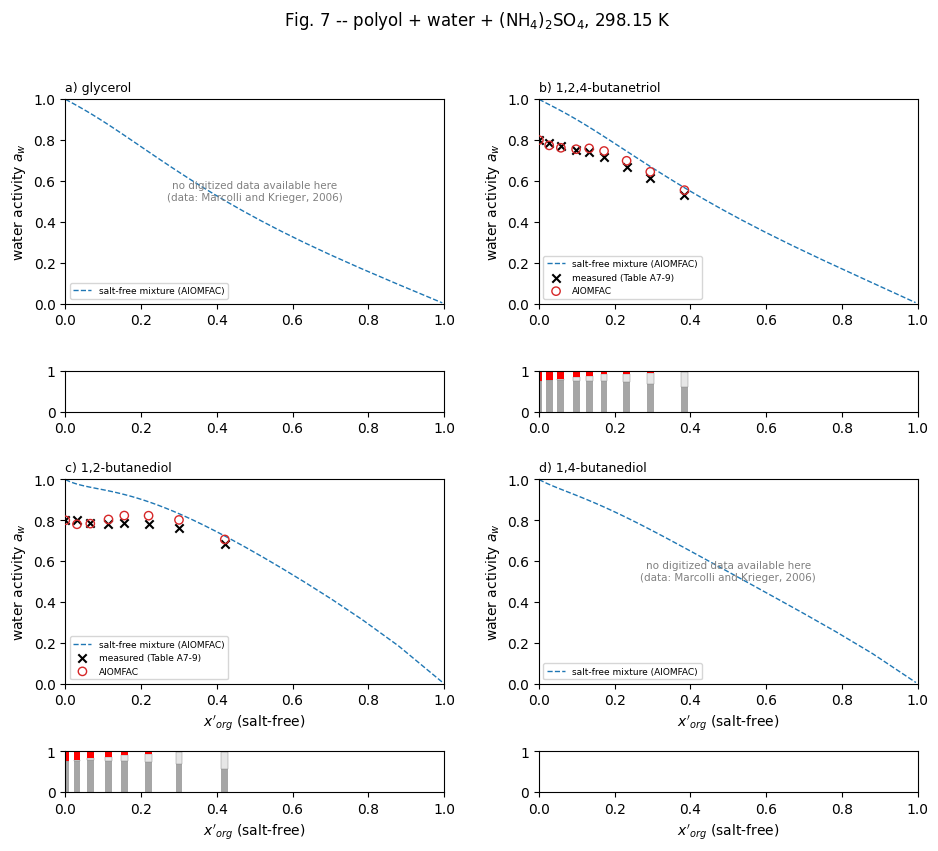

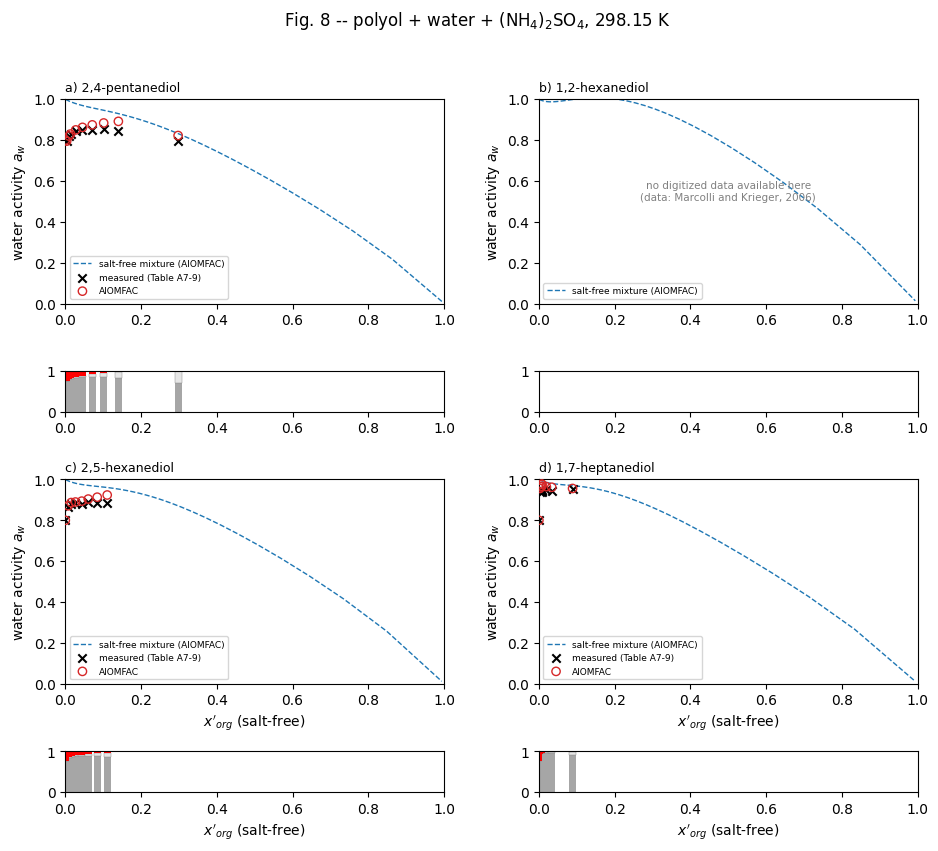

In [7]:
polyols = {
    "glycerol":           ((150, 2), (151, 1), (153, 3)),
    "1,2,4-butanetriol":  ((142, 1), (150, 2), (151, 1), (153, 3)),
    "1,2-butanediol":     ((145, 1), (146, 1), (150, 1), (151, 1), (153, 2)),
    "1,4-butanediol":     ((142, 2), (150, 2), (153, 2)),
    "2,4-pentanediol":    ((141, 2), (142, 1), (151, 2), (153, 2)),
    "1,2-hexanediol":     ((145, 1), (146, 3), (150, 1), (151, 1), (153, 2)),
    "2,5-hexanediol":     ((141, 2), (142, 2), (151, 2), (153, 2)),
    "1,7-heptanediol":    ((142, 5), (150, 2), (153, 2)),
}
M_polyol = {
    "glycerol": 92.09, "1,2,4-butanetriol": 106.12, "1,2-butanediol": 90.12, "1,4-butanediol": 90.12,
    "2,4-pentanediol": 104.15, "1,2-hexanediol": 118.17, "2,5-hexanediol": 118.17, "1,7-heptanediol": 132.20,
}
M_nh4so4 = 132.14

# Appendix A data (this study, bulk AquaLab measurements, 298.15 K): (NH4)2SO4 wf, polyol wf, a_w
appendix_data = {
    "1,2,4-butanetriol": np.array([
        [0.0158, 0.7737, 0.531], [0.0364, 0.6845, 0.614], [0.0680, 0.5961, 0.668],
        [0.1055, 0.4922, 0.716], [0.1580, 0.3992, 0.743], [0.2249, 0.3030, 0.750],
        [0.2966, 0.1872, 0.769], [0.3615, 0.0903, 0.787], [0.4320, 0.0000, 0.802],
    ]),
    "1,2-butanediol": np.array([
        [0.0150, 0.7726, 0.683], [0.0304, 0.6613, 0.761], [0.0797, 0.5384, 0.780],
        [0.1355, 0.4149, 0.787], [0.1980, 0.3142, 0.784], [0.2821, 0.1875, 0.787],
        [0.3540, 0.0888, 0.802], [0.4320, 0.0000, 0.802],
    ]),
    "2,4-pentanediol": np.array([
        [0.0073, 0.7051, 0.796], [0.0461, 0.4627, 0.846], [0.0900, 0.3592, 0.852],
        [0.1373, 0.2649, 0.851], [0.1971, 0.1731, 0.851], [0.2575, 0.1046, 0.845],
        [0.3304, 0.0507, 0.830], [0.3608, 0.0342, 0.820], [0.4190, 0.0121, 0.795],
        [0.4320, 0.0000, 0.802],
    ]),
    "2,5-hexanediol": np.array([
        [0.0433, 0.4299, 0.883], [0.0736, 0.3488, 0.883], [0.1083, 0.2654, 0.889],
        [0.1480, 0.1955, 0.882], [0.1902, 0.1241, 0.886], [0.2302, 0.0725, 0.879],
        [0.2911, 0.0338, 0.867], [0.4320, 0.0000, 0.802],
    ]),
    "1,7-heptanediol": np.array([
        [0.0144, 0.4111, 0.952], [0.0327, 0.1983, 0.943], [0.0477, 0.1218, 0.946],
        [0.0453, 0.0511, 0.948], [0.0480, 0.0536, 0.943], [0.0765, 0.0507, 0.941],
        [0.0981, 0.0320, 0.944], [0.1338, 0.0160, 0.938], [0.4320, 0.0000, 0.802],
    ]),
}


def polyol_panel(ax, ax_bar, name, letter):
    water = Component(1, "Water", ((16, 1),))
    org = Component(2, name, polyols[name])
    salt = Component(3, "(NH4)2SO4", ((204, 2), (261, 1)))
    model = ActivityModel([water, org, salt])
    model_sf = ActivityModel([water, org])

    f_grid = np.linspace(0.001, 0.999, 40)
    xp_sf, aw_sf = [], []
    for f in f_grid:
        res = model_sf.evaluate([1 - f, f], 298.15, basis="mass")
        n_w, n_org = res.xn[0], res.xn[1]
        xp_sf.append(n_org / (n_org + n_w)); aw_sf.append(water_activity(res))
    ax.plot(xp_sf, aw_sf, "--", color="C0", lw=1, label="salt-free mixture (AIOMFAC)")

    data = appendix_data.get(name)
    if data is not None:
        xp_list, aw_model, Xw, Xorg, Xions = [], [], [], [], []
        for w_salt, w_org, aw_meas in data:
            w_w = 1 - w_salt - w_org
            res = model.evaluate([w_w, w_org, w_salt], 298.15, basis="mass")
            n_w, n_org = res.xn[0], res.xn[1]
            xp_list.append(n_org / (n_org + n_w))
            aw_model.append(res.activity[0])
            Xw.append(res.x[0]); Xorg.append(res.x[1]); Xions.append(res.x[2:].sum())
        ax.scatter(xp_list, data[:, 2], marker="x", color="k", zorder=5, label="measured (Table A7-9)")
        ax.scatter(xp_list, aw_model, marker="o", facecolors="none", edgecolors="C3", zorder=5, label="AIOMFAC")
        order = np.argsort(xp_list)
        xp_a, Xw_a, Xorg_a, Xions_a = (np.array(v)[order] for v in (xp_list, Xw, Xorg, Xions))
        width = 0.018
        ax_bar.bar(xp_a, Xw_a, width=width, color="0.65", label="$X_w$")
        ax_bar.bar(xp_a, Xorg_a, width=width, bottom=Xw_a, color="0.9", edgecolor="0.5", lw=0.3, label="$X_{org}$")
        ax_bar.bar(xp_a, Xions_a, width=width, bottom=Xw_a + Xorg_a, color="red", label="$X_{ions}$")
    else:
        ax.text(0.5, 0.55, "no digitized data available here\n(data: Marcolli and Krieger, 2006)",
                transform=ax.transAxes, ha="center", va="center", fontsize=7.5, color="gray")
    ax_bar.set_xlim(0, 1); ax_bar.set_ylim(0, 1); ax_bar.set_yticks([0, 1])
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f"{letter}) {name}", fontsize=9, loc="left")
    ax.set_ylabel("water activity $a_w$")
    ax.legend(fontsize=6.5, loc="lower left")


def polyol_figure(fig_title, panels):
    fig = plt.figure(figsize=(11, 9))
    gs = fig.add_gridspec(4, 2, height_ratios=[3, 0.6, 3, 0.6], hspace=0.55, wspace=0.25)
    fig.suptitle(fig_title)
    for i, (name, letter) in enumerate(panels):
        row, col = (0, i) if i < 2 else (2, i - 2)
        ax = fig.add_subplot(gs[row, col])
        ax_bar = fig.add_subplot(gs[row + 1, col])
        polyol_panel(ax, ax_bar, name, letter)
        if row == 2:
            ax.set_xlabel("$x'_{org}$ (salt-free)")
            ax_bar.set_xlabel("$x'_{org}$ (salt-free)")
    plt.show()


polyol_figure("Fig. 7 -- polyol + water + (NH$_4$)$_2$SO$_4$, 298.15 K",
              [("glycerol", "a"), ("1,2,4-butanetriol", "b"),
               ("1,2-butanediol", "c"), ("1,4-butanediol", "d")])
polyol_figure("Fig. 8 -- polyol + water + (NH$_4$)$_2$SO$_4$, 298.15 K",
              [("2,4-pentanediol", "a"), ("1,2-hexanediol", "b"),
               ("2,5-hexanediol", "c"), ("1,7-heptanediol", "d")])


## Figure 9 -- NaCl-induced liquid-liquid equilibrium (salting-out)

**This one cannot be made pixel-for-pixel identical to the paper, and it's worth being explicit about why.** The paper's actual Fig. 9 is *not* a binodal-composition plot -- it is a validation plot of the **relative activity deviation between the two coexisting LLE phases** (Eq. 45 of the paper,
$|\text{rel. activity deviation}| = |a_j^\alpha - a_j^\beta| / (0.5(a_j^\alpha + a_j^\beta))$), computed at each of several *literally measured* tie-line compositions of NaCl + 1-propanol/2-propanol/isobutanol/tert-butanol + water (from Chou et al. 1998; Gomis et al. 1994, 1996), plotted against a mixture number. We do not have that digitized tie-line dataset (it isn't in this paper's own Appendix, unlike Figs. 6-8) -- computing Eq. 45 from *our own* solver's converged phases would be close to tautological (`solve_pep` enforces equal activities in both phases as its convergence criterion, to `tol=1e-9`), so it would not actually reproduce what the paper's Fig. 9 is testing.

What we *can* faithfully reproduce is the underlying physical phenomenon for all four of the paper's alcohols (not just two, as in the previous version of this section), using the new `aiomfac_py.lle` module (a port of the primal-dual interior-point/active-set Gibbs-energy minimization algorithm of Amundson, Caboussat, He & Seinfeld, 2006, *JOTA* 130(3), 375-407 -- the algorithm behind the UHAERO aerosol model). See `src/aiomfac_py/lle.py`'s module docstring for exactly what is and is not faithful to that paper. Below: binodal curves (phase compositions vs. feed composition) for NaCl + each of 1-propanol, 2-propanol, isobutanol, and tert-butanol + water, all at 298.15 K -- 1-propanol and 2-propanol are fully miscible with water on their own (confirmed below) and only phase-split once NaCl is added ("salting out"); isobutanol and tert-butanol already have a narrow miscibility gap without any salt, which NaCl widens.

1-propanol + water, no salt -- number of phases at 10 compositions: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


2-propanol + water, no salt -- number of phases at 10 compositions: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


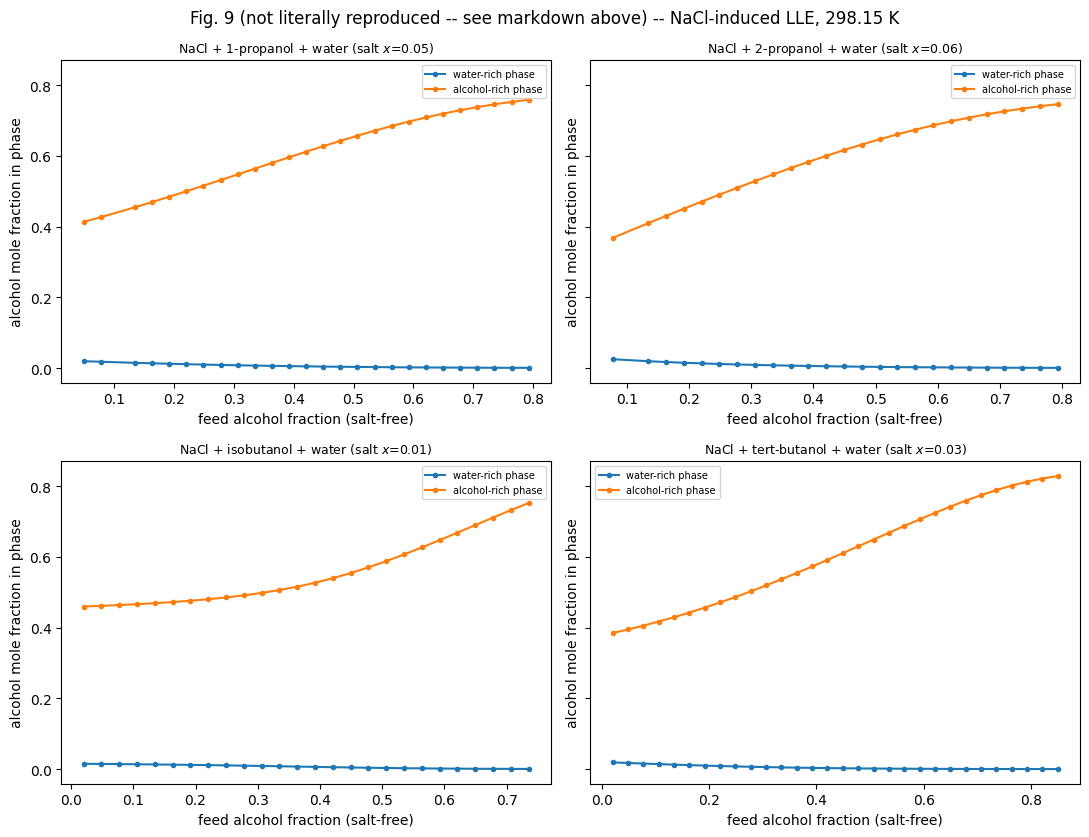

In [8]:
from aiomfac_py.lle import solve_pep


def n_real_phases(res, y_min=1e-3, dx_min=1e-3):
    """Number of phases in `res`, discarding numerically spurious near-zero-weight phases whose
    composition barely differs from another phase (an occasional artifact of the interior-point solver
    lingering near a boundary rather than a real phase split -- see lle.py's module docstring)."""
    keep = [i for i in range(len(res.y)) if res.y[i] > y_min]
    if len(keep) <= 1:
        return 1
    xs = res.x[keep]
    for i in range(len(keep)):
        for j in range(i + 1, len(keep)):
            if np.max(np.abs(xs[i] - xs[j])) > dx_min:
                return len(keep)
    return 1


alcohol_subgroups = {
    "1-propanol":    ((145, 1), (146, 1), (150, 1), (153, 1)),
    "2-propanol":    ((141, 2), (151, 1), (153, 1)),
    "isobutanol":    ((145, 2), (147, 1), (150, 1), (153, 1)),
    "tert-butanol":  ((141, 3), (152, 1), (153, 1)),
}
water = Component(1, "Water", ((16, 1),))

# confirm 1-propanol and 2-propanol + water alone (no salt) are fully miscible at every composition tried:
for name in ["1-propanol", "2-propanol"]:
    alcohol = Component(2, name, alcohol_subgroups[name])
    phases = [n_real_phases(solve_pep([water, alcohol], [1 - f, f], 298.15, tol=1e-9))
              for f in np.linspace(0.05, 0.95, 10)]
    print(f"{name} + water, no salt -- number of phases at 10 compositions: {phases}")
    assert set(phases) == {1}, f"expected fully miscible (1 phase) everywhere for {name} without salt"


def binodal_sweep(alcohol_sg, x_salt, alcohol_frac_grid, T_K=298.15):
    alcohol = Component(2, "alcohol", alcohol_sg)
    nacl = Component(3, "NaCl", ((202, 1), (242, 1)))
    tie_lines = []
    for f in alcohol_frac_grid:
        xa = f * (1 - x_salt)
        xw = (1 - f) * (1 - x_salt)
        res = solve_pep([water, alcohol, nacl], [xw, xa, x_salt], T_K, tol=1e-9, max_outer=300)
        if res.converged and n_real_phases(res) == 2:
            keep = [i for i in range(len(res.y)) if res.y[i] > 1e-3]
            tie_lines.append((f, res.x[keep]))
    return tie_lines


settings = [("1-propanol", 0.05), ("2-propanol", 0.06), ("isobutanol", 0.01), ("tert-butanol", 0.03)]
fig, axes = plt.subplots(2, 2, figsize=(11, 8.5), sharey=True)
fig.suptitle("Fig. 9 (not literally reproduced -- see markdown above) -- NaCl-induced LLE, 298.15 K")
for ax, (name, x_salt) in zip(axes.flat, settings):
    grid = np.linspace(0.02, 0.85, 30)
    tie_lines = binodal_sweep(alcohol_subgroups[name], x_salt, grid)
    sorted_lines = [(f, x[np.argsort(x[:, 1])]) for f, x in tie_lines]
    branch_w = [(f, x[0][1]) for f, x in sorted_lines]
    branch_a = [(f, x[1][1]) for f, x in sorted_lines]
    if branch_w:
        fw, xw_ = zip(*branch_w); ax.plot(fw, xw_, marker="o", ms=3, label="water-rich phase")
    if branch_a:
        fa, xa_ = zip(*branch_a); ax.plot(fa, xa_, marker="o", ms=3, label="alcohol-rich phase")
    ax.set_title(f"NaCl + {name} + water (salt $x$={x_salt})", fontsize=9)
    ax.set_xlabel("feed alcohol fraction (salt-free)")
    ax.set_ylabel("alcohol mole fraction in phase")
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()


## Figure 10 -- Activity coefficients with an organic co-solvent

**(a)** NaBr + 2-propanol + water, 355 K: the paper plots the *organic's* and *water's* own mole-fraction activity coefficients ($\gamma_{org}$, $\gamma_w$) vs. $x'_{org}$ -- not the salt's mean ionic activity coefficient, which the previous version of this section plotted by mistake. Fixed here to use `res.gamma_neutral` for both. **(b)** NaCl + KCl + ethanol + water, 298.15 K: $\gamma_\pm$(NaCl) is the right quantity (unchanged), but the x-axis is fixed to $x_w$ (salts dissociated), matching the paper, instead of ethanol mass fraction.

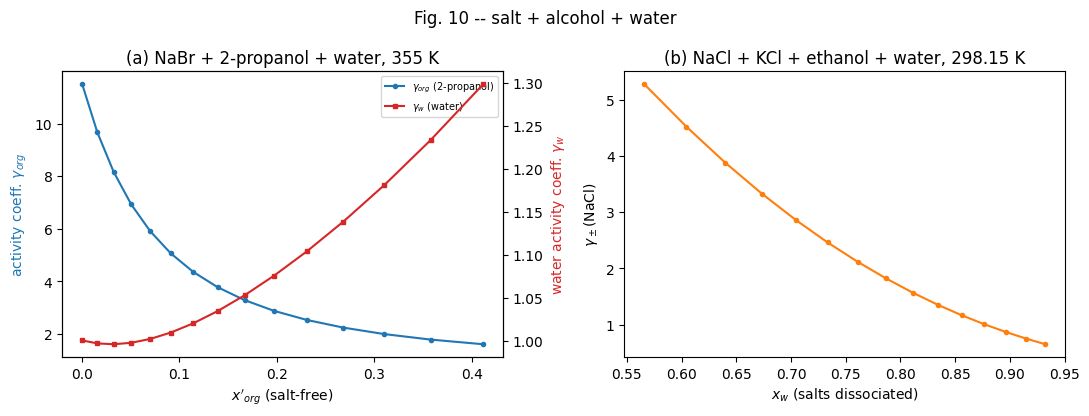

In [9]:
ethanol_sg = ((141, 1), (150, 1), (153, 1))
propan2ol_sg = ((141, 2), (151, 1), (153, 1))
M_propan2ol = 60.10


def salt_plus_alcohol_sweep(cat, an, nu_c, nu_a, M_salt, alcohol_sg, salt_molality, T_K, n=15):
    """Water + salt (fixed molality) + alcohol, sweeping alcohol mass fraction; returns (x'_org,
    gamma_org, gamma_w)."""
    water = Component(1, "Water", ((16, 1),))
    alcohol = Component(2, "alcohol", alcohol_sg)
    salt = Component(3, "salt", ((cat, nu_c), (an, nu_a)))
    model = ActivityModel([water, alcohol, salt])
    w_salt0 = salt_molality * M_salt / 1000.0
    alco_fracs = np.linspace(0.001, 0.7, n)
    xp, g_org, g_w = [], [], []
    for f in alco_fracs:
        w_water = 1.0 - f
        tot = w_water + w_salt0 + f
        res = model.evaluate([w_water / tot, f / tot, w_salt0 / tot], T_K, basis="mass")
        n_w, n_org = res.xn[0], res.xn[1]
        xp.append(n_org / (n_org + n_w))
        g_org.append(res.gamma_neutral[1])
        g_w.append(res.gamma_neutral[0])
    return np.array(xp), np.array(g_org), np.array(g_w)


xp_a, g_org_a, g_w_a = salt_plus_alcohol_sweep(202, 243, 1, 1, 102.89, propan2ol_sg, 1.0, 355.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
fig.suptitle("Fig. 10 -- salt + alcohol + water")
ax1b = ax1.twinx()
l1, = ax1.plot(xp_a, g_org_a, marker="o", ms=3, color="C0", label=r"$\gamma_{org}$ (2-propanol)")
l2, = ax1b.plot(xp_a, g_w_a, marker="s", ms=3, color="C3", label=r"$\gamma_w$ (water)")
ax1.set_xlabel("$x'_{org}$ (salt-free)")
ax1.set_ylabel(r"activity coeff. $\gamma_{org}$", color="C0")
ax1b.set_ylabel(r"water activity coeff. $\gamma_w$", color="C3")
ax1.set_title("(a) NaBr + 2-propanol + water, 355 K")
ax1.legend(handles=[l1, l2], fontsize=7)

water = Component(1, "Water", ((16, 1),))
ethanol = Component(2, "ethanol", ethanol_sg)
nacl = Component(3, "NaCl", ((202, 1), (242, 1)))
kcl = Component(4, "KCl", ((203, 1), (242, 1)))
model_b = ActivityModel([water, ethanol, nacl, kcl])
eth_fracs = np.linspace(0.001, 0.6, 15)
xw_b10, g_nacl = [], []
for f in eth_fracs:
    w_water = 1 - f
    w_nacl = 1.0 * 58.44 / 1000.0
    w_kcl = 1.0 * 74.55 / 1000.0
    tot = w_water + f + w_nacl + w_kcl
    res = model_b.evaluate([w_water / tot, f / tot, w_nacl / tot, w_kcl / tot], 298.15, basis="mass")
    xw_b10.append(res.x[0])
    g_nacl.append(mean_gamma_pm(model_b, res, 202, 242, 1, 1))
ax2.plot(xw_b10, g_nacl, marker="o", ms=3, color="C1")
ax2.set_xlabel("$x_w$ (salts dissociated)"); ax2.set_ylabel(r"$\gamma_\pm$(NaCl)")
ax2.set_title("(b) NaCl + KCl + ethanol + water, 298.15 K")
plt.tight_layout(); plt.show()


## Summary

All eight figures (3, 4, 5, 6, 7, 8, 9, 10) are addressed using `aiomfac_py`, now checked figure-by-figure against the actual published paper (not just against the general topic each figure covers):

| Figure | Correspondence |
|---|---|
| 3, 4 | Same salts, same axes ($x_w$, $a_w$, $\gamma_\pm$), extended into the same supersaturated regime the paper's own curves cover. |
| 5 | Same two $x_w$ conventions (full/partial HSO4⁻ dissociation), same 1:1/2:1/3:1 mixing ratios, validated against our own Appendix A (Table A1) data. |
| 6 | Same real molar ratios (Table A3, A5), same $x_w$ axis, ZSR comparison added (computed from our own binary curves, not the paper's cited polynomials). |
| 7, 8 | Same 8 polyols, same panel layout with phase-composition bar charts; 5 of 8 panels validated against our own Appendix A data (Tables A7-A9), the other 3 (data from Marcolli and Krieger, 2006) show the model curve only, with no data we have access to. |
| 9 | **Not the same figure.** The paper's Fig. 9 needs external, undigitized tie-line data we don't have; shown instead is the new `aiomfac_py.lle` module's own binodal-curve prediction, for all four of the paper's alcohols, which is qualitatively the same phenomenon (NaCl salting out an alcohol) but not the same plot. |
| 10 | Panel (a) now plots the correct quantities ($\gamma_{org}$, $\gamma_w$, previously plotted $\gamma_\pm$(NaBr) by mistake); panel (b) axis fixed to $x_w$. |

Figures 3-8 and 10 use only the pre-existing, Fortran-validated electrolyte/dissociation/organic-subgroup machinery, plus notebook-level post-processing. Figure 9's qualitative demonstration relies on the new `aiomfac_py.lle` module (a port of the primal-dual interior-point Gibbs-energy minimization algorithm behind the UHAERO aerosol model, Amundson et al. 2006, JOTA 130), validated on its own against an independently, analytically solvable toy phase-split problem (`tests/test_lle.py`), since there is no Fortran/AIOMFAC-LLE reference to check the *combination* with `aiomfac_py`'s activity-coefficient core against.